# Crash / Accident Detection From CCTV Footage — CNN Classifier



## Download the dataset

In [3]:
!pip install -q kagglehub opencv-python-headless

In [2]:
import kagglehub

path = kagglehub.dataset_download("ckay16/accident-detection-from-cctv-footage")

100%|██████████| 249M/249M [00:08<00:00, 32.2MB/s]

Extracting files...


In [4]:
!find "{path}" -maxdepth 3 -type d

/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val/Non Accident
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val/Accident
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Non Accident
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Accident
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/No

## Discover the folder layout


In [5]:
import os
from typing import Dict, List, Tuple

def find_split_dirs(root: str) -> Dict[str, str]:
    """Locate the train/val/test split directories under `root`.

    Args:
        root: Root directory returned by kagglehub.dataset_download.

    Returns:
        Mapping from split name ("train", "val", "test") to its directory
        path, for whichever splits actually exist in the dataset.
    """
    splits: Dict[str, str] = {}
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            key = d.lower()
            if key in ("train", "training"):
                splits["train"] = os.path.join(dirpath, d)
            elif key in ("test", "testing"):
                splits["test"] = os.path.join(dirpath, d)
            elif key in ("val", "valid", "validation"):
                splits["val"] = os.path.join(dirpath, d)
    return splits


def find_class_dirs(split_dir: str) -> Dict[str, str]:
    """List immediate subfolders of a split directory as class -> path."""
    return {
        name: os.path.join(split_dir, name)
        for name in sorted(os.listdir(split_dir))
        if os.path.isdir(os.path.join(split_dir, name))
    }


split_dirs = find_split_dirs(path)
print("Splits found:", split_dirs)

# Use "train" as the main pool of labeled data; fall back to "test" if a
# dedicated validation split isn't provided.
train_dir = split_dirs.get("train")
test_dir = split_dirs.get("test") or split_dirs.get("val")

train_classes = find_class_dirs(train_dir)
test_classes = find_class_dirs(test_dir) if test_dir else {}

print("Train classes:", train_classes)
print("Test/val classes:", test_classes)

Splits found: {'val': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val', 'test': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test', 'train': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train'}
Train classes: {'Accident': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/Accident', 'Non Accident': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/Non Accident'}
Test/val classes: {'Accident': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Accident', 'Non Accident': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Non Accident'}


## Imports & constants

In [6]:
import random

import cv2  # image I/O, resizing, color-space handling
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (128, 128)  # matches the 128x128 preprocessing used in the reference project
BATCH_SIZE = 32          # kept modest to avoid the OOM crash from the original notebook
NUM_CHANNELS = 3

# Class order is fixed here so label indices are stable and reproducible.
CLASS_NAMES: List[str] = sorted(train_classes.keys())
CLASS_TO_LABEL = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print("Class -> label mapping:", CLASS_TO_LABEL)

Class -> label mapping: {'Accident': 0, 'Non Accident': 1}


## Load images with OpenCV

In [7]:
def load_images_and_labels(directory: str, label: int) -> Tuple[List[np.ndarray], List[int]]:
    """Load every image in `directory`, resize it, and pair it with `label`.

    Args:
        directory: Folder containing image files for a single class.
        label: Integer class label to assign to every image in `directory`.

    Returns:
        A tuple of (images, labels) as parallel Python lists.
    """
    images: List[np.ndarray] = []
    labels: List[int] = []
    image_files = [
        f for f in os.listdir(directory)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    for filename in image_files:
        filepath = os.path.join(directory, filename)
        image = cv2.imread(filepath)
        if image is None:
            continue  # skip unreadable/corrupted files instead of crashing the whole load
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR; keep RGB for consistency
        image = cv2.resize(image, IMAGE_SIZE)
        images.append(image)
        labels.append(label)
    return images, labels


def load_split(class_dirs: Dict[str, str]) -> Tuple[np.ndarray, np.ndarray]:
    """Load and concatenate every class folder in a split into arrays."""
    all_images: List[np.ndarray] = []
    all_labels: List[int] = []
    for class_name, class_dir in class_dirs.items():
        label = CLASS_TO_LABEL[class_name]
        print(f"Loading '{class_name}' images from {class_dir} ...")
        imgs, lbls = load_images_and_labels(class_dir, label)
        print(f"  -> loaded {len(imgs)} images")
        all_images.extend(imgs)
        all_labels.extend(lbls)
    return np.array(all_images), np.array(all_labels)


X_train_full, y_train_full = load_split(train_classes)
print(f"Total labeled images loaded: {len(X_train_full)}")

Loading 'Accident' images from /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/Accident ...
  -> loaded 369 images
Loading 'Non Accident' images from /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/Non Accident ...
  -> loaded 422 images
Total labeled images loaded: 791


## Visualize class balance and sample images



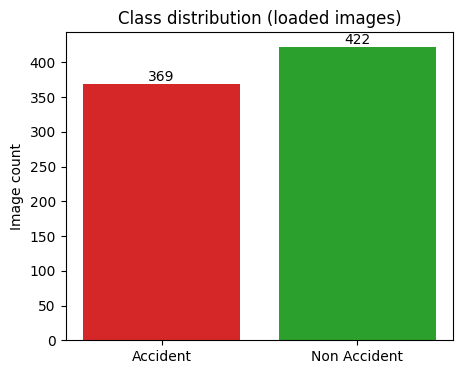

In [8]:
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(5, 4))
plt.bar([CLASS_NAMES[u] for u in unique], counts, color=["#d62728", "#2ca02c"])
plt.title("Class distribution (loaded images)")
plt.ylabel("Image count")
for i, c in enumerate(counts):
    plt.text(i, c, str(c), ha="center", va="bottom")
plt.show()

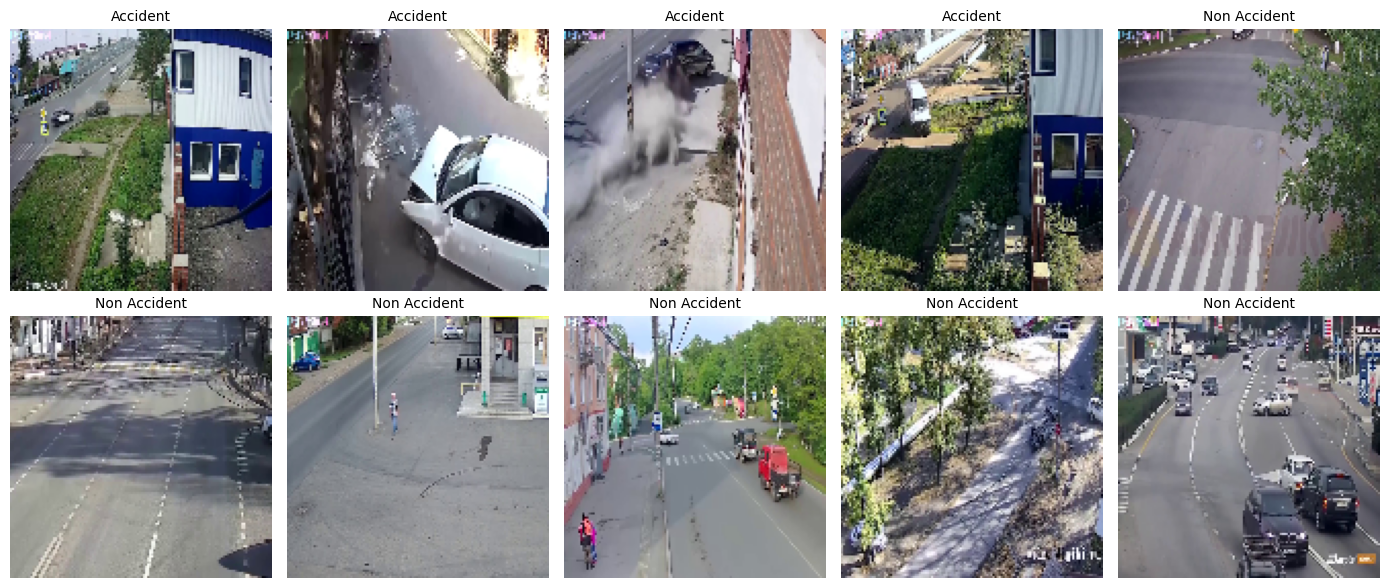

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_idx = np.random.choice(len(X_train_full), size=10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_train_full[idx])
    ax.set_title(CLASS_NAMES[y_train_full[idx]], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Preprocess: normalize + train / validation / test split


In [10]:
X_train_full = X_train_full.astype("float32") / 255.0  # scale pixels to [0, 1]

if test_classes:
    X_test, y_test = load_split(test_classes)
    X_test = X_test.astype("float32") / 255.0
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=0.15, random_state=SEED, stratify=y_train_full,
    )
else:
    # No separate test split shipped with the dataset: carve train/val/test
    # out of the single pool (70/15/15), stratified on the label.
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_train_full, y_train_full,
        test_size=0.30, random_state=SEED, stratify=y_train_full,
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50, random_state=SEED, stratify=y_temp,
    )

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Loading 'Accident' images from /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Accident ...
  -> loaded 47 images
Loading 'Non Accident' images from /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Non Accident ...
  -> loaded 53 images
Train: (672, 128, 128, 3), Val: (119, 128, 128, 3), Test: (100, 128, 128, 3)


## Data augmentation


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_augmenter = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
)
train_augmenter.fit(X_train)

train_generator = train_augmenter.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

## Build the CNN

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(*IMAGE_SIZE, NUM_CHANNELS)),

    keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),  # -> (128, 128, 32)
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),                                    # -> (64, 64, 32)

    keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),  # -> (64, 64, 64)
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),                                    # -> (32, 32, 64)
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"), # -> (32, 32, 128)
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),                                    # -> (16, 16, 128)
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(256, (3, 3), padding="same", activation="relu"), # -> (16, 16, 256)
    keras.layers.GlobalAveragePooling2D(),                                # -> (256,)  replaces Flatten to keep param count sane

    keras.layers.Dense(128, activation="relu"),                          # -> (128,)
    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),          # -> (num_classes,)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,466 (1.61 MB)

 Trainable params: 422,018 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

##  Compile

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # fixed the invalid "Adamw" string from the original notebook
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Callbacks

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_accident_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
)

## Train

In [16]:
EPOCHS = 30

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr, checkpoint],
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.5298 - loss: 0.8596 - val_accuracy: 0.5294 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.5372 - loss: 0.7303 - val_accuracy: 0.5294 - val_loss: 0.6983 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.5045 - loss: 0.7390 - val_accuracy: 0.5294 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5476 - loss: 0.6944 - val_accuracy: 0.5294 - val_loss: 0.7013 - learning_rate: 0.0010
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5580 - loss: 0.6922 - val_accuracy: 0.5294 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.5685 - loss: 0.6860 - val_accuracy: 0.5294 - val_loss: 0.7073 - learning_rate: 5.0000e-04
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.5446 - loss: 0.69

## Training curves



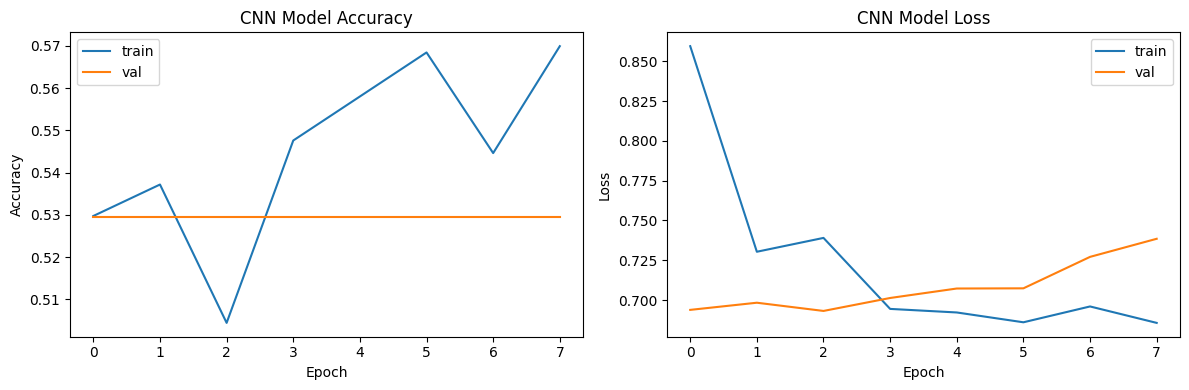

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("CNN Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("CNN Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

##  Evaluate on the held-out test set

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss:     {test_loss:.4f}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test accuracy: 0.5300
Test loss:     0.6937

Classification report:
              precision    recall  f1-score   support

    Accident       0.00      0.00      0.00        47
Non Accident       0.53      1.00      0.69        53

    accuracy                           0.53       100
   macro avg       0.27      0.50      0.35       100
weighted avg       0.28      0.53      0.37       100



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


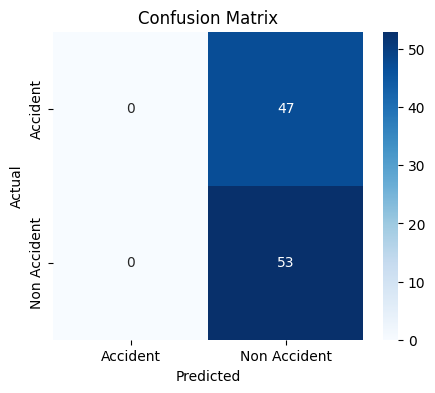

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Single-image inference



In [ ]:
def predict_image(filepath: str, model: keras.Model) -> Tuple[str, float]:

    image = cv2.imread(filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMAGE_SIZE).astype("float32") / 255.0
    probs = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
    predicted_label = int(np.argmax(probs))
    return CLASS_NAMES[predicted_label], float(probs[predicted_label])


label, confidence = predict_image("/path/to/frame.jpg", model)
print(f"Prediction: {label} ({confidence:.2%} confidence)")

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


##  Emergency email alert

The reference project's key contribution beyond classification is emailing
a snapshot to a responder whenever an accident is detected. This is left
as an opt-in helper — fill in real SMTP credentials via environment
variables before enabling it, and never commit credentials to the
notebook.

In [ ]:
import smtplib
from email.mime.image import MIMEImage
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText


def send_accident_alert(
    image_path: str,
    recipient_email: str,
    sender_email: str,
    sender_password: str,
    smtp_server: str = "smtp.gmail.com",
    smtp_port: int = 587,
) -> None:
    """Email a detected-accident frame to a responder.

    Credentials should come from environment variables / a secrets manager,
    never hard-coded in the notebook.
    """
    msg = MIMEMultipart()
    msg["Subject"] = "Accident Detected — Immediate Attention Required"
    msg["From"] = sender_email
    msg["To"] = recipient_email
    msg.attach(MIMEText("An accident was detected by the CCTV monitoring system. See attached frame."))

    with open(image_path, "rb") as f:
        msg.attach(MIMEImage(f.read(), name="accident_frame.jpg"))

    with smtplib.SMTP(smtp_server, smtp_port) as server:
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)


# Example (disabled by default):
# send_accident_alert(
#     image_path="/path/to/frame.jpg",
#     recipient_email="responder@example.com",
#     sender_email=os.environ["ALERT_SENDER_EMAIL"],
#     sender_password=os.environ["ALERT_SENDER_PASSWORD"],
# )

##  Save the trained model

In [ ]:
model.save("accident_detection_cnn.keras")
print("Saved model to accident_detection_cnn.keras")